In [5]:
import pandas as pd

df = pd.read_csv("../public derived dataset", dtype=str, keep_default_na=False)
df.head()

,case_id,analysis_group,category,variable,value,evidence_quality
0,Case_A,core,Support Matrix,SCH_INF,3,E2
1,Case_B,core,Support Matrix,SCH_INF,4,E3
2,Case_C,boundary,Support Matrix,SCH_INF,1,E3
3,Case_D,core,Support Matrix,SCH_INF,2,E3
4,Case_E,core,Support Matrix,SCH_INF,0,E3


In [6]:
print("表格大小（行数，列数）：", df.shape)
print("案例数量：", df["case_id"].nunique())

表格大小（行数，列数）： (406, 6)
案例数量： 7


In [7]:
df["category"].value_counts()

category
Support Matrix     245
Source-Specific    119
ILL                 42
Name: count, dtype: int64

In [8]:
df["value"].value_counts()

value
NR      151
3        51
4        42
0        42
2        40
1        38
UNC      34
NAPP      8
Name: count, dtype: int64

In [9]:
record_status = df["value"].replace(["0", "1", "2", "3", "4"], "Numeric")
status_counts = record_status.value_counts()
status_counts

value
Numeric    213
NR         151
UNC         34
NAPP         8
Name: count, dtype: int64

In [10]:
record_status = df["value"].replace(["0", "1", "2", "3", "4"], "Numeric")
status_counts = record_status.value_counts()
status_counts

value
Numeric    213
NR         151
UNC         34
NAPP         8
Name: count, dtype: int64

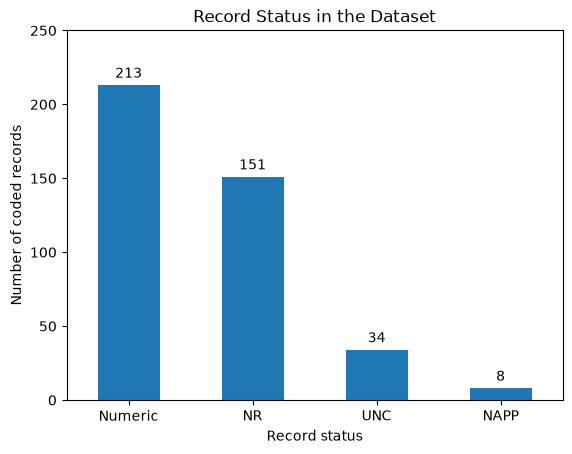

In [11]:
import matplotlib.pyplot as plt

ax = status_counts.plot(kind="bar", rot=0)
plt.title("Record Status in the Dataset")
plt.xlabel("Record status")
plt.ylabel("Number of coded records")
ax.bar_label(ax.containers[0], padding=3)
plt.ylim(0, 250)
plt.show()

### Record status overview
This chart shows the number of coded records in each status category. Records with numeric values form the largest group, totaling 213. NR means “not reported” and should not be treated as a score of 0, because missing information does not mean that something is absent.

In [12]:
ill_df = df.loc[df["category"] == "ILL"].copy()
ill_df.head(7)

,case_id,analysis_group,category,variable,value,evidence_quality
364,Case_A,core,ILL,ILL_INF,NR,
365,Case_B,core,ILL,ILL_INF,NR,
366,Case_C,boundary,ILL,ILL_INF,2,E1
367,Case_D,core,ILL,ILL_INF,3,E3
368,Case_E,core,ILL,ILL_INF,4,E3
369,Case_F,core,ILL,ILL_INF,1,E3
370,Case_G,core,ILL,ILL_INF,2,E3


In [13]:
ill_matrix = ill_df.pivot(
    index="case_id",
    columns="variable",
    values="value"
)

ill_matrix

variable,ILL_EMO,ILL_INF,ILL_PLN,ILL_RES,ILL_TASK,ILL_VER
case_id,,,,,,
Case_A,1,NR,1,NR,2,2
Case_B,2,NR,3,1,4,2
Case_C,UNC,2,2,2,3,4
Case_D,UNC,3,4,4,4,NR
Case_E,2,4,3,1,4,2
Case_F,3,1,2,4,4,4
Case_G,NR,2,3,4,4,4


In [14]:
ill_numeric = ill_matrix.apply(pd.to_numeric, errors="coerce")
ill_numeric

variable,ILL_EMO,ILL_INF,ILL_PLN,ILL_RES,ILL_TASK,ILL_VER
case_id,,,,,,
Case_A,1.0,NaN,1,NaN,2,2.0
Case_B,2.0,NaN,3,1.0,4,2.0
Case_C,NaN,2.0,2,2.0,3,4.0
Case_D,NaN,3.0,4,4.0,4,NaN
Case_E,2.0,4.0,3,1.0,4,2.0
Case_F,3.0,1.0,2,4.0,4,4.0
Case_G,NaN,2.0,3,4.0,4,4.0


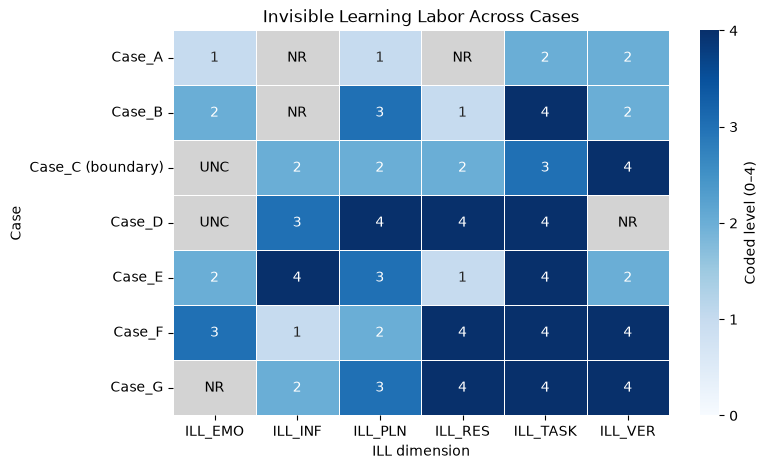

In [23]:
import seaborn as sns

plt.figure(figsize=(8, 5))
ax = sns.heatmap(
    ill_numeric,
    cmap="Blues",
    vmin=0,
    vmax=4,
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    cbar_kws={"ticks": [0, 1, 2, 3, 4], "label": "Coded level (0–4)"},
    yticklabels=ill_numeric.index.str.replace("Case_C", "Case_C (boundary)", regex=False)
)   
for row in range(ill_numeric.shape[0]):
    for col in range(ill_numeric.shape[1]):
        if pd.isna(ill_numeric.iloc[row, col]):
            ax.text(
                col + 0.5,
                row + 0.5,
                ill_matrix.iloc[row, col],
                ha="center",
                va="center",
                color="black"
            )

plt.yticks(rotation=0)
ax.set_facecolor("lightgray")
plt.title("Invisible Learning Labor Across Cases")
plt.xlabel("ILL dimension")
plt.ylabel("Case")
plt.show()

### How to read this heatmap

Each row represents a case, and each column represents an invisible learning labor (ILL) dimension. Darker blue indicates a higher coded level within that dimension.

Codes range from 0 to 4 and are ordinal: the distances between levels are not assumed to be equal. Gray cells indicate NR (not reported) or UNC (unclear); neither is treated as 0.

Case_C is included as a boundary case. This figure provides a descriptive overview of the seven cases.